<a href="https://colab.research.google.com/github/Tanishq7361/Forced-Damped-Oscillator-Simulation/blob/main/Forced_Damped_Oscillator_and_Resonance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Forced-Damped Oscillators, Resonance and Beats

## Q1. Forced-Damped Oscillator

$$\ddot{x} + 2\beta\dot{x} + \omega_0^2 x = F_0\cos(\omega t)$$

**Parameters:** $F_0 = 1$, $\omega_0 = 2.5$, $\beta = 0.5$

**Initial conditions:** $x(0) = 0$, $\dot{x}(0) = 1$

Reduce to first-order system with $v = \dot{x}$:
$$\dot{x} = v, \qquad \dot{v} = F_0\cos(\omega t) - 2\beta v - \omega_0^2 x$$

---

### Q1(a): Transient and Steady-State Behaviour at $\omega = 0.3$

The general solution of a forced-damped oscillator is the sum of two parts:

$$x(t) = \underbrace{x_{\text{transient}}(t)}_{\to 0 \text{ as } t\to\infty} + \underbrace{x_{\text{steady}}(t)}_{\text{persists forever}}$$

- **Transient:** the homogeneous solution $\sim e^{-\beta t}\cos(\omega_d t + \phi)$, which decays exponentially at rate $\beta$. It depends on initial conditions and dies out.
- **Steady-state:** the particular solution $\sim A\cos(\omega t - \delta)$, driven at the forcing frequency $\omega$. It persists indefinitely.

For $\beta = 0.5$, the transient decays on a timescale of $1/\beta = 2$ seconds. By $t \approx 5/\beta = 10$ s it is essentially gone.

---

### Q1(a): Transient and Steady-State Behaviour at $\omega = 0.3$

The general solution of a forced-damped oscillator is the sum of two parts:

$$x(t) = \underbrace{x_{\text{transient}}(t)}_{\to 0 \text{ as } t\to\infty} + \underbrace{x_{\text{steady}}(t)}_{\text{persists forever}}$$

- **Transient:** the homogeneous solution $\sim e^{-\beta t}\cos(\omega_d t + \phi)$, which decays exponentially at rate $\beta$. It depends on initial conditions and dies out.
- **Steady-state:** the particular solution $\sim A\cos(\omega t - \delta)$, driven at the forcing frequency $\omega$. It persists indefinitely.

For $\beta = 0.5$, the transient decays on a timescale of $1/\beta = 2$ seconds. By $t \approx 5/\beta = 10$ s it is essentially gone.

---

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [16]:
F0 = 1
w0 = 2.5
beta = 0.5

In [17]:
def oscillator(t, y, omega):
    x, v = y
    dxdt = v
    dvdt = F0*np.cos(omega*t) - 2*beta*v - w0**2*x
    return [dxdt, dvdt]

In [18]:
def solve_oscillator(omega, t_end=100,n_points=15000):
    t_eval = np.linspace(0, t_end, 10000)
    sol = solve_ivp(
        oscillator,
        [0, t_end],
        [0, 1],
        args=(omega,),
        t_eval=t_eval
    )
    return sol.t, sol.y[0]

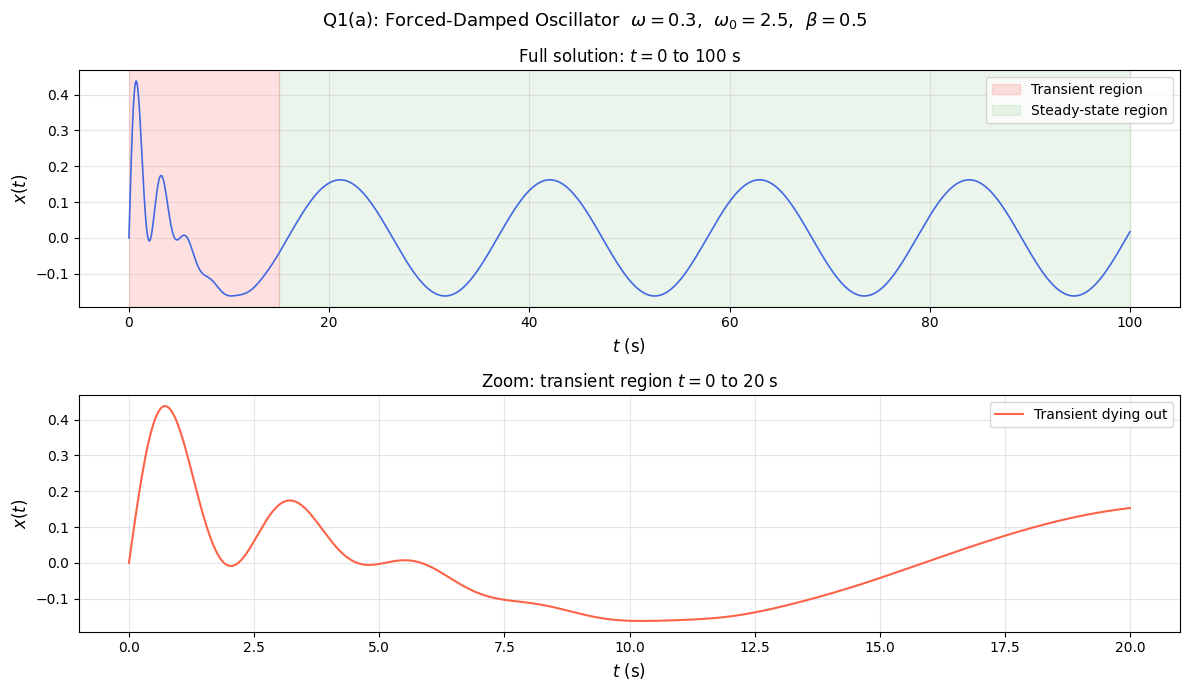

Steady-state amplitude at ω=0.3: 0.1621


In [19]:
t, x = solve_oscillator(omega=0.3, t_end=100)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
fig.suptitle(r'Q1(a): Forced-Damped Oscillator  $\omega=0.3$,  $\omega_0=2.5$,  $\beta=0.5$', fontsize=13)

# Full solution
axes[0].plot(t, x, color='royalblue', linewidth=1.2)
axes[0].axvspan(0, 15, alpha=0.12, color='red',   label='Transient region')
axes[0].axvspan(15, 100, alpha=0.08, color='green', label='Steady-state region')
axes[0].set_xlabel('$t$ (s)', fontsize=12)
axes[0].set_ylabel('$x(t)$', fontsize=12)
axes[0].set_title('Full solution: $t = 0$ to $100$ s')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Zoom into transient
mask_t = t < 20
axes[1].plot(t[mask_t], x[mask_t], color='tomato', linewidth=1.5, label='Transient dying out')
axes[1].set_xlabel('$t$ (s)', fontsize=12)
axes[1].set_ylabel('$x(t)$', fontsize=12)
axes[1].set_title('Zoom: transient region $t = 0$ to $20$ s')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Steady-state amplitude
x_steady = x[t > 80]
print(f'Steady-state amplitude at ω=0.3: {(x_steady.max() - x_steady.min())/2:.4f}')

### Q1(b): Resonance — Three Values of $\omega$

The steady-state amplitude of a forced-damped oscillator is:
$$A(\omega) = \frac{F_0}{\sqrt{(\omega_0^2 - \omega^2)^2 + 4\beta^2\omega^2}}$$

Resonance occurs when $A(\omega)$ is maximised. Differentiating and setting to zero gives:
$$\omega_{\text{res}} = \sqrt{\omega_0^2 - 2\beta^2}$$

For our parameters: $\omega_{\text{res}} = \sqrt{2.5^2 - 2(0.5)^2} = \sqrt{6.25 - 0.5} = \sqrt{5.75} \approx 2.398$

We test three values:
- $\omega < \omega_0$: below resonance
- $\omega = \omega_0 = 2.5$: at natural frequency
- $\omega > \omega_0$: above resonance

---

Resonance frequency: ω_res = √(ω₀² - 2β²) = 2.3979 rad/s


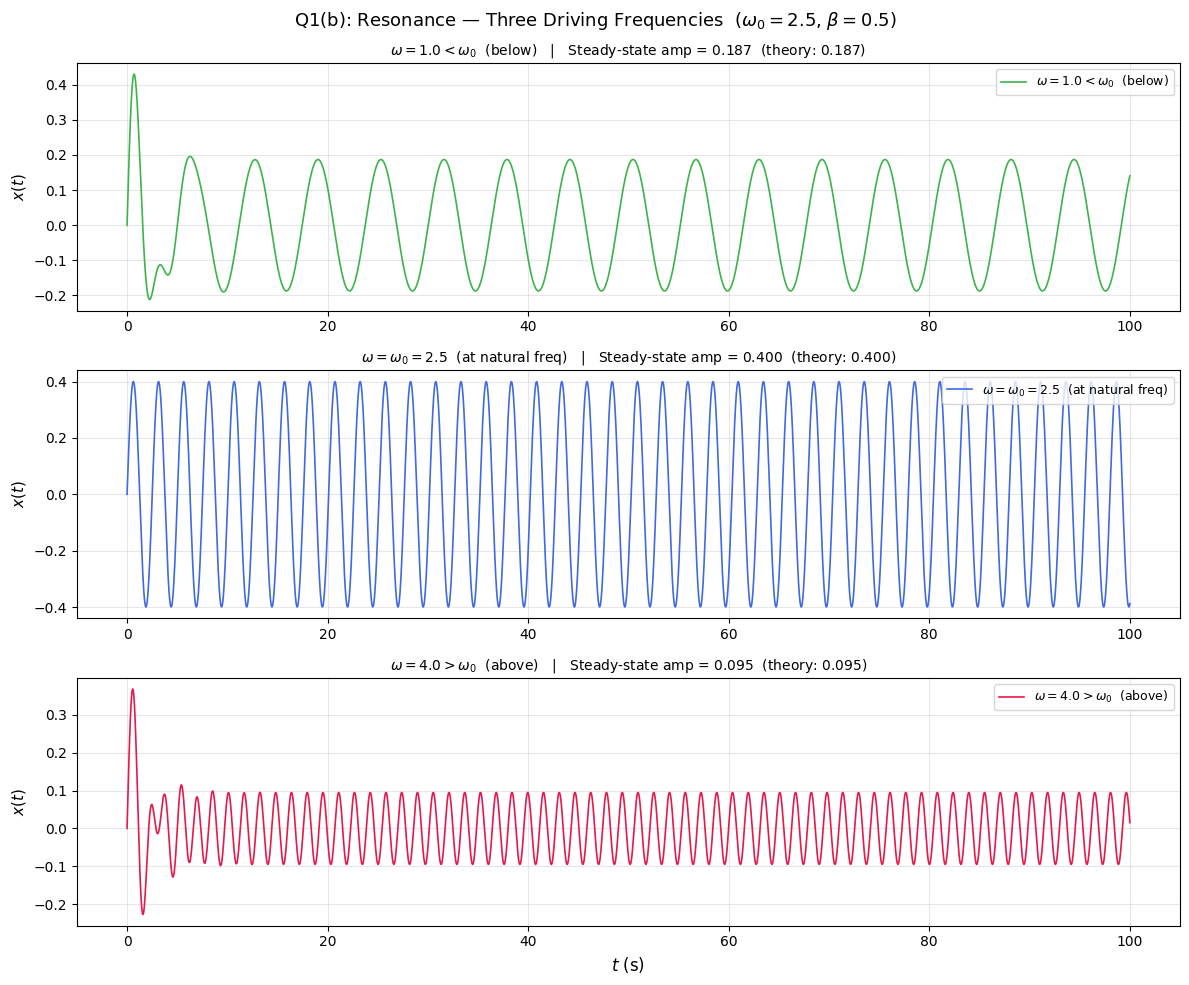

In [20]:
w_res = np.sqrt(w0**2 - 2*beta**2)
print(f'Resonance frequency: ω_res = √(ω₀² - 2β²) = {w_res:.4f} rad/s')

omega_vals  = [1.0, w0, 4.0]
labels      = [r'$\omega = 1.0 < \omega_0$  (below)',
               r'$\omega = \omega_0 = 2.5$  (at natural freq)',
               r'$\omega = 4.0 > \omega_0$  (above)']
colors      = ['#3cb44b', 'royalblue', '#e6194b']

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)
fig.suptitle(r'Q1(b): Resonance — Three Driving Frequencies  ($\omega_0 = 2.5$, $\beta = 0.5$)', fontsize=13)

for ax, omega, label, color in zip(axes, omega_vals, labels, colors):
    t, x = solve_oscillator(omega=omega, t_end=100)
    x_ss = x[t > 80]
    amp  = (x_ss.max() - x_ss.min()) / 2
    A_theory = F0 / np.sqrt((w0**2 - omega**2)**2 + 4*beta**2*omega**2)
    ax.plot(t, x, color=color, linewidth=1.2, label=label)
    ax.set_ylabel('$x(t)$', fontsize=11)
    ax.set_title(f'{label}   |   Steady-state amp = {amp:.3f}  (theory: {A_theory:.3f})', fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('$t$ (s)', fontsize=12)
plt.tight_layout()
plt.show()

### Q1(c): Amplitude vs Driving Frequency — Resonance Curve

We sweep $\omega$ from near zero to well above $\omega_0$ and measure the steady-state amplitude at each value. This produces the **resonance curve** (or frequency response curve).

---

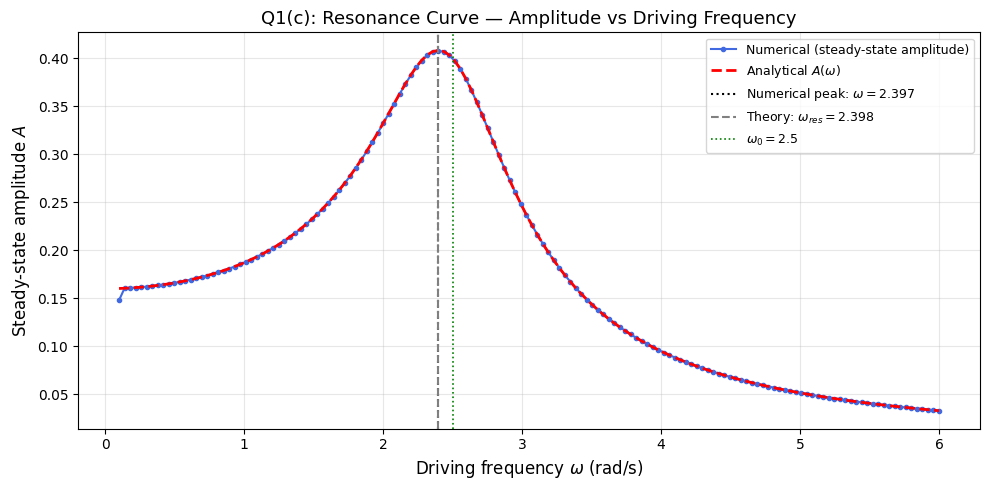

Peak amplitude      : 0.4079
At driving frequency: ω = 2.3966 rad/s
Theory predicts     : ω_res = 2.3979 rad/s
Natural frequency   : ω₀ = 2.5000 rad/s
Note: ω_res < ω₀ because damping shifts the resonance peak downward


In [21]:
omega_sweep = np.linspace(0.1, 6.0, 150)
amplitudes  = []

for omega in omega_sweep:
    t, x = solve_oscillator(omega=omega, t_end=150, n_points=15000)
    x_ss = x[t > 100]          # take only the last portion (steady state)
    amp  = (x_ss.max() - x_ss.min()) / 2
    amplitudes.append(amp)

amplitudes = np.array(amplitudes)
omega_peak = omega_sweep[np.argmax(amplitudes)]

# Theoretical amplitude curve
A_theory = F0 / np.sqrt((w0**2 - omega_sweep**2)**2 + 4*beta**2*omega_sweep**2)

plt.figure(figsize=(10, 5))
plt.plot(omega_sweep, amplitudes, 'o-', color='royalblue', linewidth=1.5,
         markersize=3, label='Numerical (steady-state amplitude)')
plt.plot(omega_sweep, A_theory, 'r--', linewidth=2, label='Analytical $A(\\omega)$')
plt.axvline(x=omega_peak, color='black', linestyle=':', linewidth=1.5,
            label=f'Numerical peak: $\\omega = {omega_peak:.3f}$')
plt.axvline(x=w_res, color='gray', linestyle='--', linewidth=1.5,
            label=f'Theory: $\\omega_{{res}} = {w_res:.3f}$')
plt.axvline(x=w0, color='green', linestyle=':', linewidth=1.2,
            label=f'$\\omega_0 = {w0}$')
plt.xlabel('Driving frequency $\\omega$ (rad/s)', fontsize=12)
plt.ylabel('Steady-state amplitude $A$', fontsize=12)
plt.title('Q1(c): Resonance Curve — Amplitude vs Driving Frequency', fontsize=13)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Peak amplitude      : {amplitudes.max():.4f}')
print(f'At driving frequency: ω = {omega_peak:.4f} rad/s')
print(f'Theory predicts     : ω_res = {w_res:.4f} rad/s')
print(f'Natural frequency   : ω₀ = {w0:.4f} rad/s')
print(f'Note: ω_res < ω₀ because damping shifts the resonance peak downward')

### Q1 Observations

- The resonance peak occurs at $\omega_{\text{res}} = \sqrt{\omega_0^2 - 2\beta^2} < \omega_0$. Damping shifts the peak **below** the natural frequency.
- At $\omega \ll \omega_0$: amplitude $\approx F_0/\omega_0^2$ — quasi-static response, oscillator just follows the force.
- At $\omega = \omega_{\text{res}}$: amplitude is maximum — resonance.
- At $\omega \gg \omega_0$: amplitude $\approx F_0/\omega^2 \to 0$ — oscillator cannot follow fast forcing.
- Numerical and analytical curves match closely, confirming the simulation is correct.

---

## Q2. Undamped Oscillator — Beats and Resonance

$$\ddot{x} + x = \cos(\omega t), \quad x(0) = 0,\ x'(0) = 0$$

Here $\omega_0 = 1$ (natural frequency). There is **no damping** ($\beta = 0$).

---

### Analytical Solution

**Case 1: $\omega \neq 1$ (off resonance)**

The general solution is:
$$x(t) = C_1\cos(t) + C_2\sin(t) + \frac{1}{1-\omega^2}\cos(\omega t)$$

Applying $x(0) = 0$: $C_1 + \frac{1}{1-\omega^2} = 0 \implies C_1 = -\frac{1}{1-\omega^2}$

Applying $x'(0) = 0$: $C_2 = 0$

So:
$$x(t) = \frac{1}{1-\omega^2}\left[\cos(\omega t) - \cos(t)\right]$$

Using the identity $\cos A - \cos B = -2\sin\!\left(\frac{A+B}{2}\right)\sin\!\left(\frac{A-B}{2}\right)$:

$$\boxed{x(t) = \frac{-2}{1-\omega^2}\sin\!\left(\frac{(1+\omega)t}{2}\right)\sin\!\left(\frac{(1-\omega)t}{2}\right)}$$

This is a **beat pattern**: a fast oscillation at frequency $\frac{1+\omega}{2}$ modulated by a slow envelope at frequency $\frac{|1-\omega|}{2}$. As $\omega \to 1$, the beat period $\to \infty$ and the amplitude $\to \infty$.

**Case 2: $\omega = 1$ (exact resonance)**

The forcing frequency equals the natural frequency. The particular solution is no longer $\cos(\omega t)/(1-\omega^2)$ (that diverges). Instead:
$$x(t) = \frac{t}{2}\sin(t)$$

The amplitude grows **linearly with time** — unbounded growth. This is pure resonance.

---

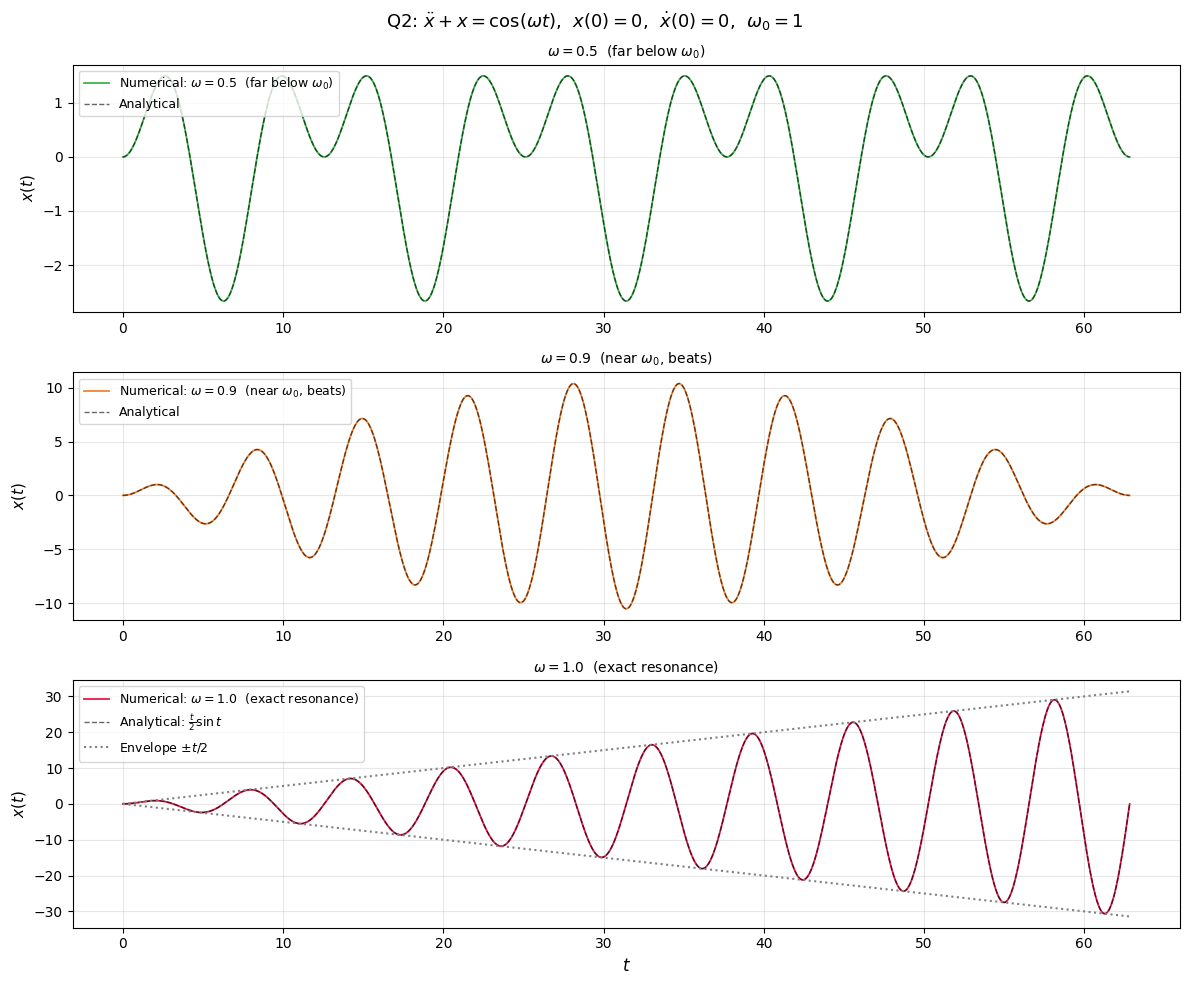

In [22]:
def undamped_rhs(t, state, omega):
    x, v = state
    return [v, np.cos(omega*t) - x]

def solve_undamped(omega, t_end=20*np.pi, n_points=5000):
    sol = solve_ivp(undamped_rhs, [0, t_end], [0.0, 0.0],
                    args=(omega,), method='RK45',
                    t_eval=np.linspace(0, t_end, n_points),
                    rtol=1e-10, atol=1e-12)
    return sol.t, sol.y[0]

T_end = 20 * np.pi

omega_cases = [0.5, 0.9, 1.0]
labels_q2   = [r'$\omega = 0.5$  (far below $\omega_0$)',
               r'$\omega = 0.9$  (near $\omega_0$, beats)',
               r'$\omega = 1.0$  (exact resonance)']
colors_q2   = ['#3cb44b', '#f58231', '#e6194b']

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
fig.suptitle(r'Q2: $\ddot{x} + x = \cos(\omega t)$,  $x(0)=0$,  $\dot{x}(0)=0$,  $\omega_0=1$', fontsize=13)

for ax, omega, label, color in zip(axes, omega_cases, labels_q2, colors_q2):
    t, x = solve_undamped(omega=omega)
    ax.plot(t, x, color=color, linewidth=1.3, label=f'Numerical: {label}')

    # Overlay analytical solution
    if abs(omega - 1.0) > 1e-6:
        x_analytical = (np.cos(omega*t) - np.cos(t)) / (1 - omega**2)
        ax.plot(t, x_analytical, 'k--', linewidth=1, alpha=0.6, label='Analytical')
    else:
        x_analytical = 0.5 * t * np.sin(t)
        ax.plot(t, x_analytical, 'k--', linewidth=1, alpha=0.6, label='Analytical: $\\frac{t}{2}\\sin t$')
        # Plot linear growth envelope
        ax.plot(t,  t/2, 'gray', linestyle=':', linewidth=1.5, label='Envelope $\\pm t/2$')
        ax.plot(t, -t/2, 'gray', linestyle=':', linewidth=1.5)

    ax.set_ylabel('$x(t)$', fontsize=11)
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('$t$', fontsize=12)
plt.tight_layout()
plt.show()

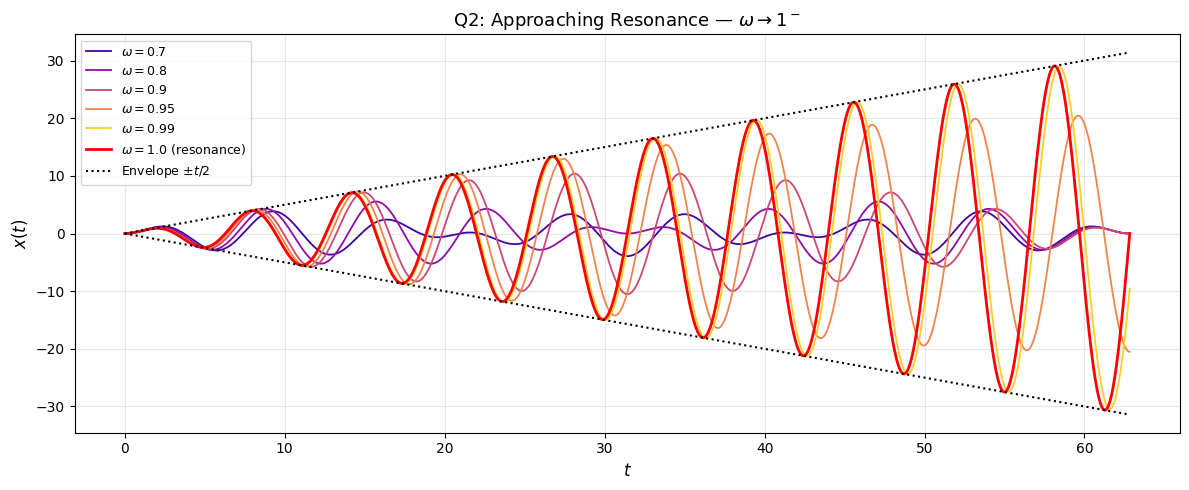

In [23]:
# Show how solution changes as omega approaches 1 from below
omega_near = [0.7, 0.8, 0.9, 0.95, 0.99]
colors_near = plt.cm.plasma(np.linspace(0.1, 0.9, len(omega_near)))

plt.figure(figsize=(12, 5))
for omega, color in zip(omega_near, colors_near):
    t, x = solve_undamped(omega=omega)
    plt.plot(t, x, color=color, linewidth=1.3, label=f'$\\omega = {omega}$')

t_res, x_res = solve_undamped(omega=1.0)
plt.plot(t_res, x_res, 'r-', linewidth=2, label='$\\omega = 1.0$ (resonance)')
plt.plot(t_res,  t_res/2, 'k:', linewidth=1.5, label='Envelope $\\pm t/2$')
plt.plot(t_res, -t_res/2, 'k:', linewidth=1.5)

plt.xlabel('$t$', fontsize=12)
plt.ylabel('$x(t)$', fontsize=12)
plt.title(r'Q2: Approaching Resonance — $\omega \to 1^-$', fontsize=13)
plt.legend(fontsize=9, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

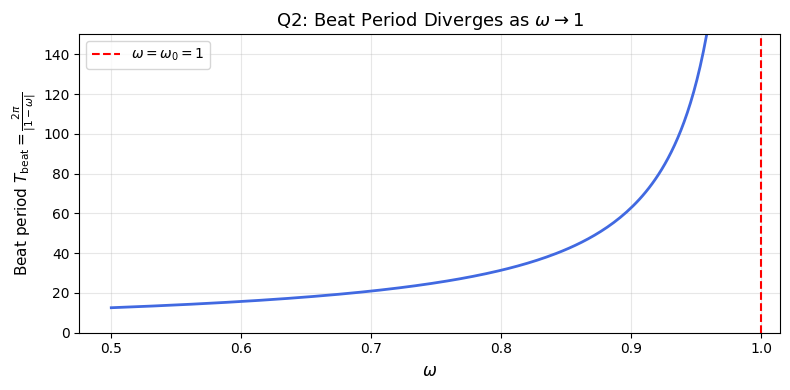

In [24]:
# Beat period vs omega — show how beat period diverges as omega -> 1
omega_beat = np.linspace(0.5, 0.99, 200)
T_beat = 2 * np.pi / np.abs(1 - omega_beat)   # period of slow envelope

plt.figure(figsize=(8, 4))
plt.plot(omega_beat, T_beat, color='royalblue', linewidth=2)
plt.xlabel('$\\omega$', fontsize=12)
plt.ylabel('Beat period $T_{\\text{beat}} = \\frac{2\\pi}{|1-\\omega|}$', fontsize=11)
plt.title('Q2: Beat Period Diverges as $\\omega \\to 1$', fontsize=13)
plt.axvline(x=1.0, color='red', linestyle='--', linewidth=1.5, label='$\\omega = \\omega_0 = 1$')
plt.legend(fontsize=10)
plt.ylim(0, 150)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Q2 Observations

| $\omega$ | Behaviour | Amplitude | Explanation |
|---|---|---|---|
| $0.5$ | Regular oscillation | Bounded, moderate | Far from resonance, beat period short |
| $0.9$ | Slow amplitude modulation (beats) | Bounded but larger | Near resonance, beat period $= 2\pi/0.1 \approx 63$ |
| $1.0$ | Secular growth | Unbounded $\sim t/2$ | Exact resonance, no damping to limit growth |

- For $\omega \neq 1$: the solution $x(t) = \frac{\cos(\omega t) - \cos t}{1-\omega^2}$ is a superposition of two cosines at different frequencies. The interference produces **beats** — periodic swelling and shrinking of amplitude.
- As $\omega \to 1$: the beat period $T_{\text{beat}} = 2\pi/|1-\omega| \to \infty$ and the beat amplitude $\to \infty$. In the limit $\omega = 1$ the solution changes character entirely to $x = (t/2)\sin t$ — linearly growing amplitude.
- With no damping ($\beta = 0$), resonance causes **unbounded growth** — completely unlike the damped case in Q1 where the amplitude saturates at a finite peak.
- Numerical and analytical solutions lie exactly on top of each other — confirming correctness.

---